# **Business Sales Forecasting using Machine Learning and Time Series Analysis**



## Objective
The goal of this project is to analyze business sales data over time and build predictive models to support strategic decision-making.

We perform:
- Data preprocessing
- Exploratory data analysis
- Feature engineering
- Machine learning modeling
- Future sales prediction

## Libraries used

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# Data Uploading

In [2]:

df=pd.read_csv("/content/DPELDATASET_realistic (2).csv")
df.head()

,Customer ID,Customer Name,Last Name,Date of Birth,Sales,Year,Outlet Type,City Type,Category of Goods,Region,...,Ship Date,Ship Mode,State,Postal Code,Product ID,Sub-Category,Product Name,Quantity,Discount,Profit
0,CUST000001,Curtis,Krause,29-11-1973,14587.86,2023.0,Large,Tier 1,Fast Food,East,...,18-04-2020,Same Day,West Bengal,700001.0,PROD000001,Burgers,Burgers - 718,3.0,0.00,6331.61
1,CUST000002,Jeremy,Foster,30-08-1987,9196.19,2022.0,Medium,Tier 2,Fast Food,East,...,11-01-2021,Standard Class,Punjab,160001.0,PROD000002,Pizzas,Pizzas - 519,1.0,0.01,983.24
2,CUST000003,Ariel,Mccann,15-12-1980,18576.69,2023.0,Large,Village,Electric Appliances,South,...,16-08-2020,Second Class,Gujarat,380001.0,PROD000003,Fans,Fans - 395,NaN,0.02,1843.67
3,CUST000004,Colleen,Maynard,23-05-1989,5558.30,2021.0,Medium,Village,Dairy Products,East,...,16-10-2021,First Class,West Bengal,700001.0,PROD000004,Milk,Milk - 798,NaN,0.40,302.91
4,CUST000005,Gina,Holden,31-12-1957,23547.11,2021.0,Small,Village,Sessional Fruits & Vegetables,West,...,25-01-2019,Standard Class,Delhi,110001.0,PROD000005,Tomatoes,Tomatoes - 442,10.0,0.09,4396.25


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Customer ID        100000 non-null  object 
 1   Customer Name      100000 non-null  object 
 2   Last Name          100000 non-null  object 
 3   Date of Birth      100000 non-null  object 
 4   Sales              89906 non-null   float64
 5   Year               89962 non-null   float64
 6   Outlet Type        100000 non-null  object 
 7   City Type          100000 non-null  object 
 8   Category of Goods  100000 non-null  object 
 9   Region             100000 non-null  object 
 10  Country            100000 non-null  object 
 11  Segment            100000 non-null  object 
 12  Sales Date         100000 non-null  object 
 13  Order ID           100000 non-null  object 
 14  Order Date         100000 non-null  object 
 15  Ship Date          100000 non-null  object 
 16  Shi

In [3]:
df.describe()

,Sales,Year,Postal Code,Quantity,Discount,Profit
count,89906.000000,89962.000000,90118.00000,90024.000000,90031.000000,80879.000000
mean,11590.788232,2020.999455,388605.87361,3.604383,0.166709,1376.811852
std,7642.387945,1.414052,184169.21179,2.569387,0.154669,1787.293573
min,101.140000,2019.000000,110001.00000,1.000000,0.000000,-3976.540000
25%,5573.230000,2020.000000,226001.00000,2.000000,0.020000,219.270000
50%,10181.830000,2021.000000,380001.00000,3.000000,0.120000,918.010000
75%,16261.575000,2022.000000,560001.00000,5.000000,0.290000,2114.120000
max,48242.600000,2023.000000,700001.00000,14.000000,0.500000,17353.670000


In [98]:
df.shape

(100000, 25)

In [4]:
df.isnull().sum()

,0
Customer ID,0
Customer Name,0
Last Name,0
Date of Birth,0
Sales,10094
Year,10038
Outlet Type,0
City Type,0
Category of Goods,0
Region,0


# Dataset Description(initial observations)

• Dataset contains business sales data.

• Some columns contain missing values.

• Time related column exists which will be used for time series analysis.

• Sales column will be used as the target variable.

## DataPreprocessing

1. imputations

In [11]:
##KNN IMPUTATION
imputer = KNNImputer(n_neighbors=5)
df['Sales'] = imputer.fit_transform(df[['Sales']])
df['Profit']=imputer.fit_transform(df[['Profit']])
df['Discount']=imputer.fit_transform(df[['Discount']])
df['Quantity']=imputer.fit_transform(df[['Quantity']])



In [12]:
## median imputation on year and postal code collumn
df.fillna(df['Year'].median(),inplace=True)
df.fillna(df['Postal Code'].median(),inplace=True)

number of null values for all collumns is zero now.

In [13]:
df.isnull().sum()

,0
Customer ID,0
Customer Name,0
Last Name,0
Date of Birth,0
Sales,0
Year,0
Outlet Type,0
City Type,0
Category of Goods,0
Region,0


In [103]:
df=df.drop_duplicates()

# EDA and Visualisation


Univariate Analysis


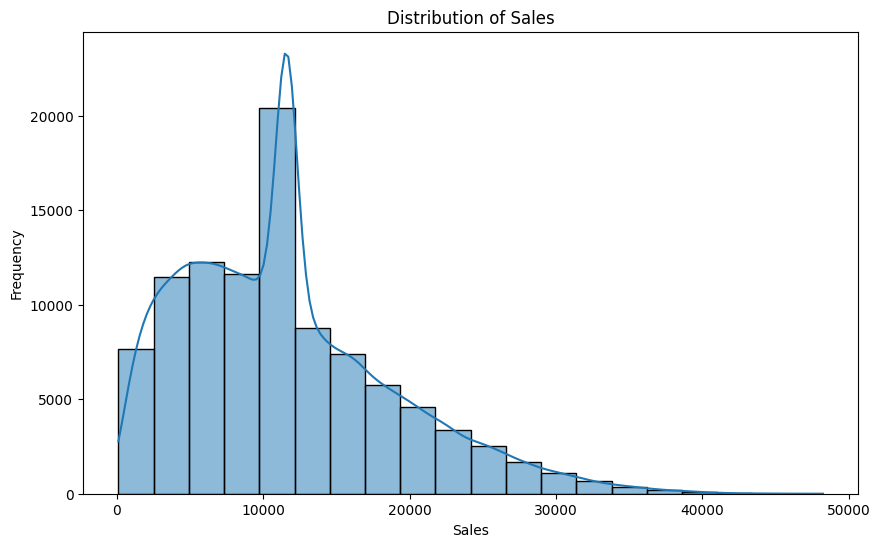

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

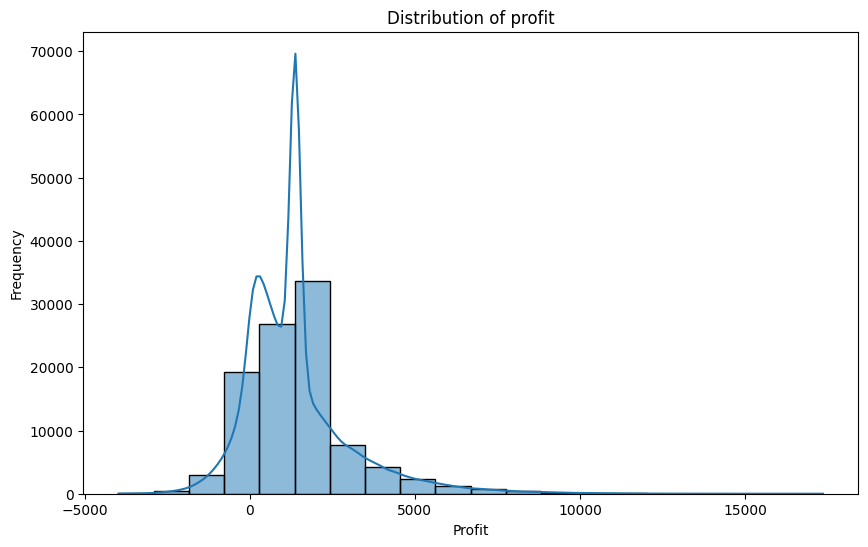

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], bins=20, kde=True)
plt.title('Distribution of profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

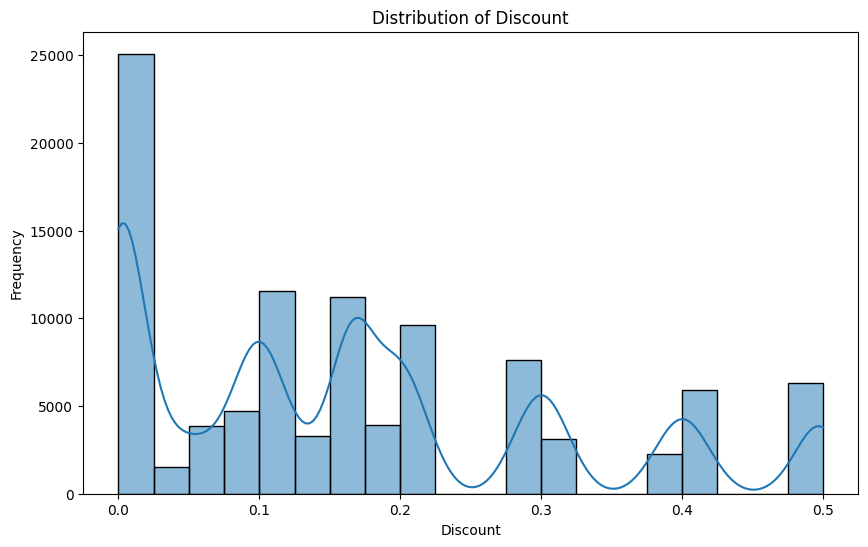

In [106]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Discount'], bins=20, kde=True)
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

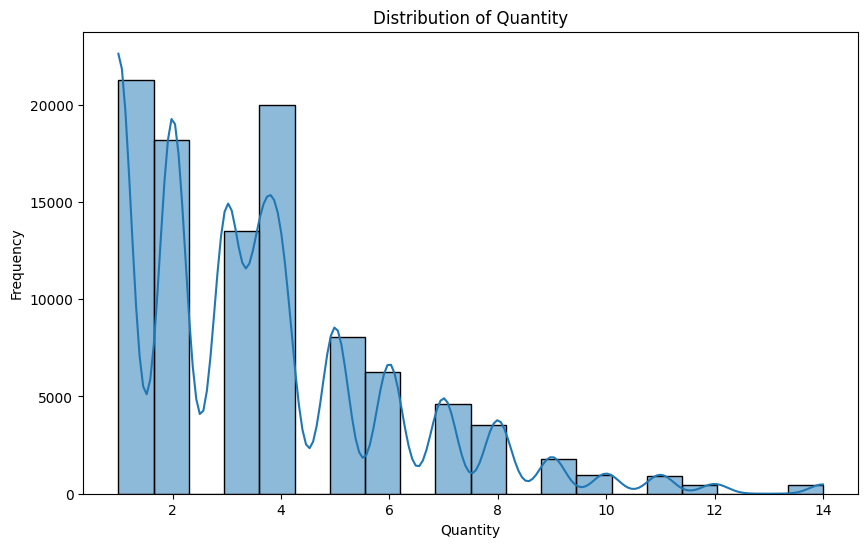

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Quantity'], bins=20, kde=True)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

## Bivariate Analysis

In [21]:
df_num=df.select_dtypes(include=['int64','float64'])
df_num.corr()

,Sales,Year,Postal Code,Quantity,Discount,Profit
Sales,1.000000,0.006538,-0.004027,0.000831,0.003372,0.478127
Year,0.006538,1.000000,0.000630,-0.000568,0.003107,0.001987
Postal Code,-0.004027,0.000630,1.000000,0.002104,0.002147,-0.003757
Quantity,0.000831,-0.000568,0.002104,1.000000,-0.004655,0.005072
Discount,0.003372,0.003107,0.002147,-0.004655,1.000000,-0.527112
Profit,0.478127,0.001987,-0.003757,0.005072,-0.527112,1.000000


<Axes: >

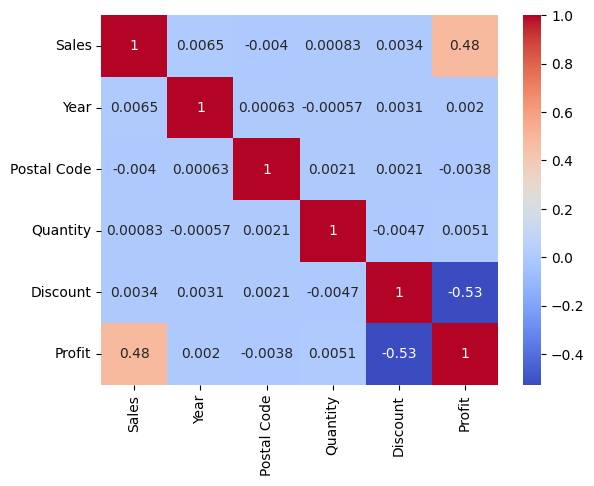

In [24]:
sns.heatmap(df_num.corr(),annot=True,cmap='coolwarm')

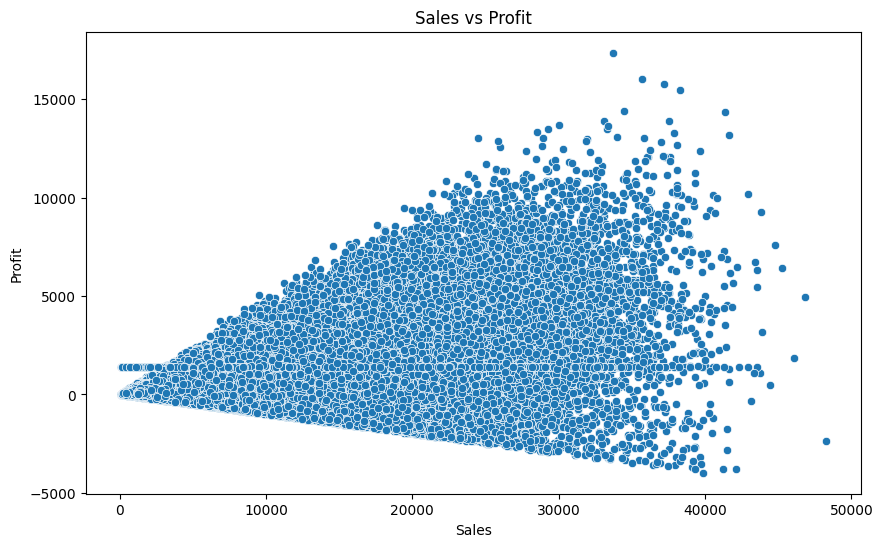

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

# Over the time analysis for time series data

/tmp/ipykernel_3327/789713585.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


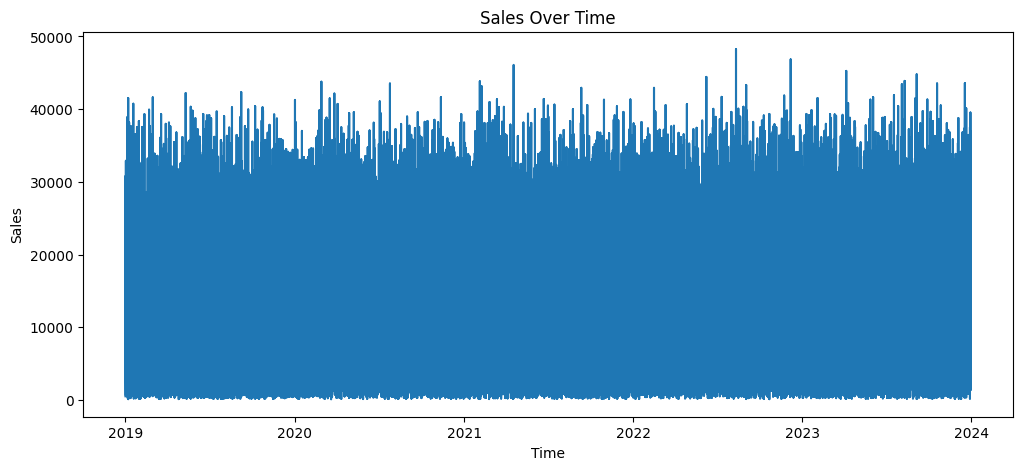

In [31]:
df['Order Date'] = pd.to_datetime(df['Order Date']) ##changed the format to datetime
df = df.sort_values('Order Date') #sorted according to date
plt.figure(figsize=(12,5))

plt.plot(df['Order Date'], df['Sales'])

plt.title("Sales Over Time")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.show()

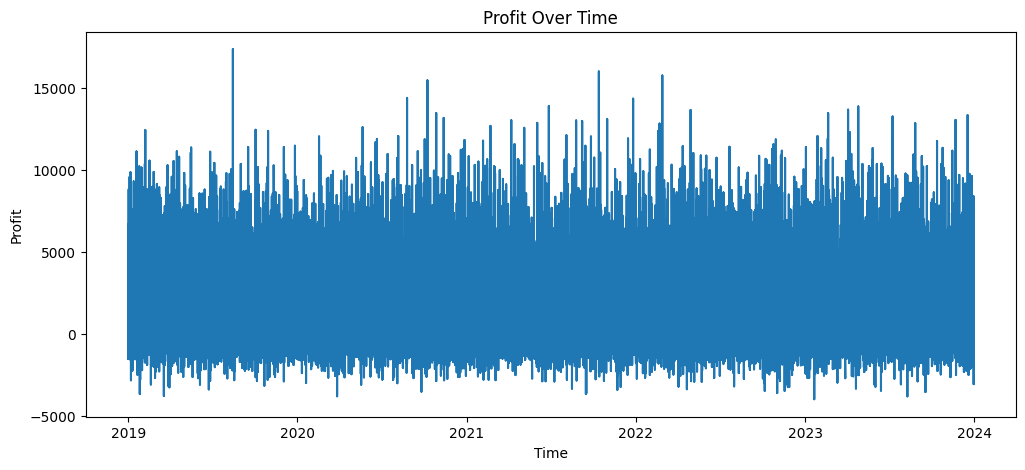

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df['Order Date'], df['Profit'])
plt.title("Profit Over Time")
plt.xlabel("Time")
plt.ylabel("Profit")
plt.show()

/tmp/ipykernel_3327/1759759052.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


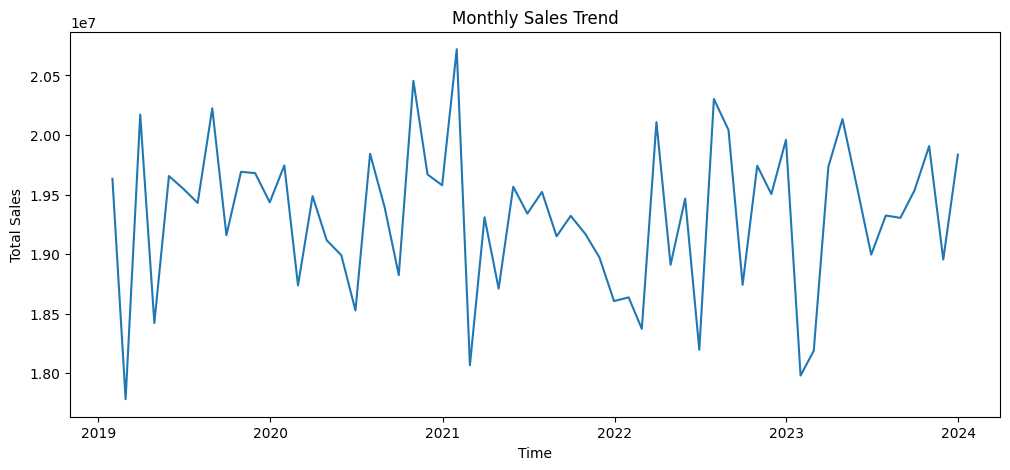

In [36]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Time")
plt.ylabel("Total Sales")

plt.show()

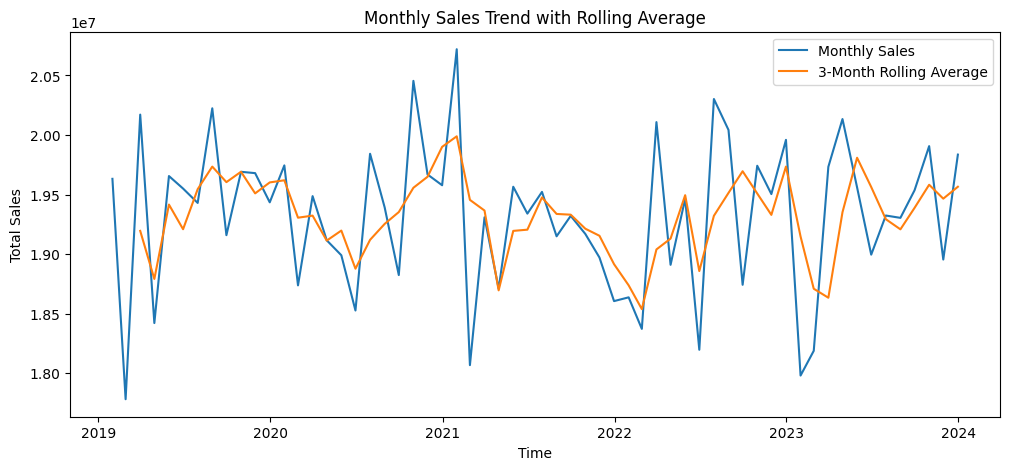

In [37]:
rolling_sales = monthly_sales.rolling(3).mean()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(rolling_sales, label="3-Month Rolling Average")

plt.title("Monthly Sales Trend with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Total Sales")

plt.legend()

plt.show()

/tmp/ipykernel_3327/1528010369.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_profit = df.resample('M', on='Order Date')['Profit'].sum()


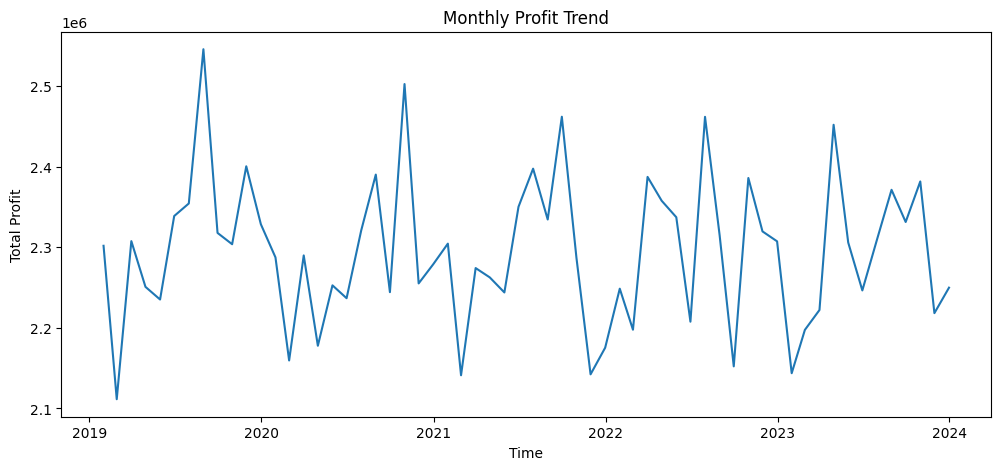

In [33]:
monthly_profit = df.resample('M', on='Order Date')['Profit'].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_profit)

plt.title("Monthly Profit Trend")
plt.xlabel("Time")
plt.ylabel("Total Profit")

plt.show()

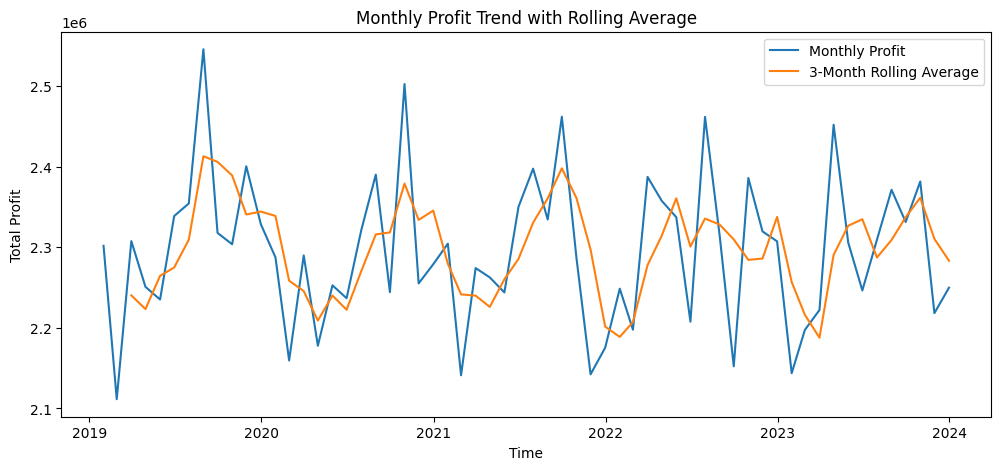

In [35]:
rolling_profit = monthly_profit.rolling(3).mean()

plt.figure(figsize=(12,5))

plt.plot(monthly_profit, label="Monthly Profit")
plt.plot(rolling_profit, label="3-Month Rolling Average")

plt.title("Monthly Profit Trend with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Total Profit")

plt.legend()

plt.show()

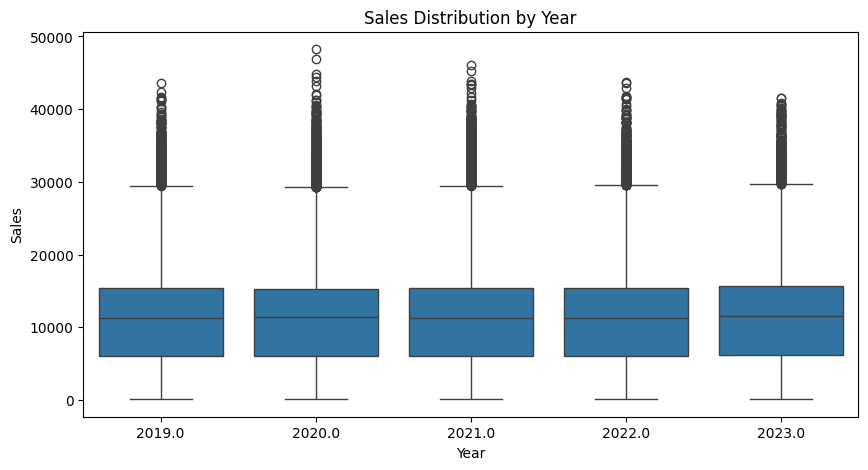

In [40]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Year'], y=df['Sales'])

plt.title("Sales Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

## Multivariate Analysis

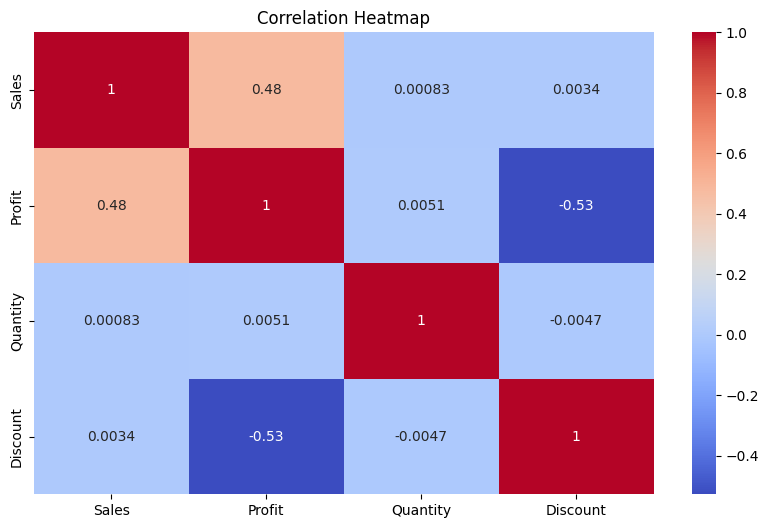

In [41]:
plt.figure(figsize=(10,6))

sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

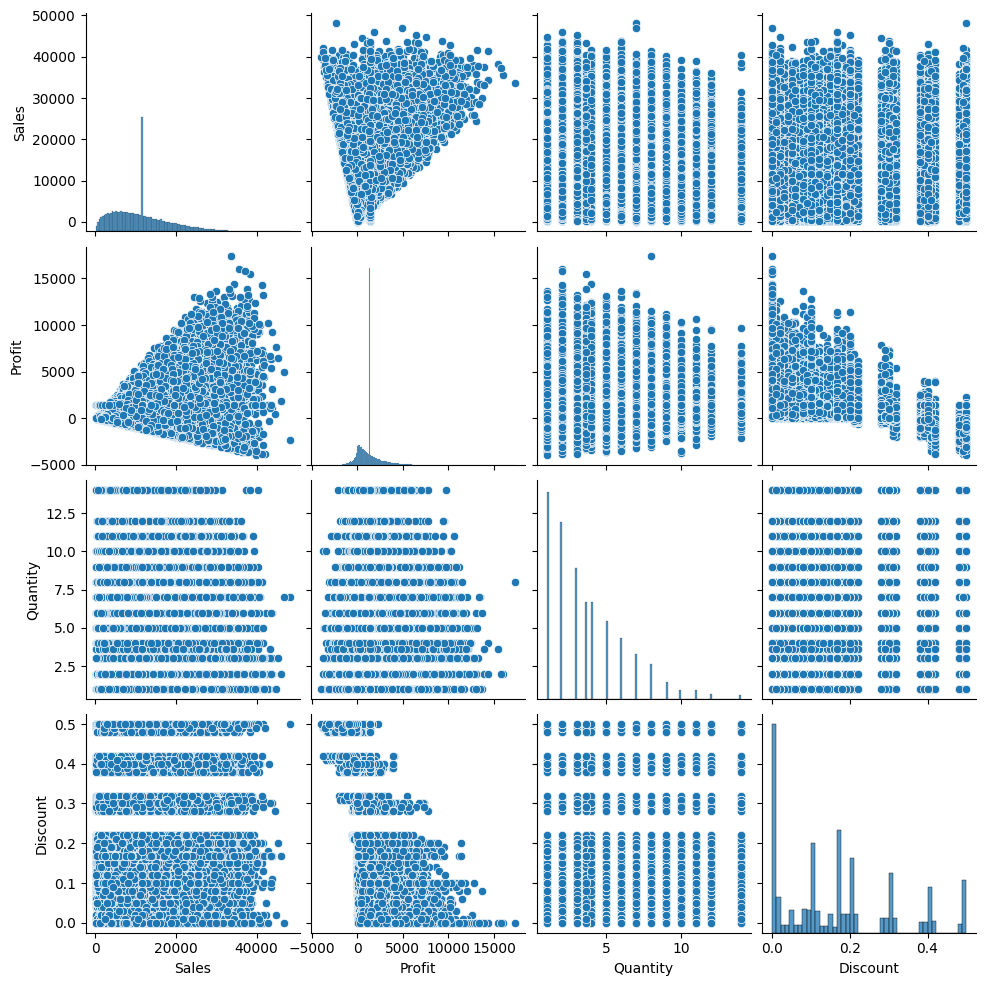

In [43]:
sns.pairplot(df[['Sales','Profit','Quantity','Discount']])

plt.show()

## Feature Engineering

In [44]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day_of_week'] = df['Order Date'].dt.dayofweek

In [45]:
df['lag1'] = df['Sales'].shift(1)
df['lag2'] = df['Sales'].shift(2)
df['lag3'] = df['Sales'].shift(3)

In [46]:
df['rolling_mean_3'] = df['Sales'].rolling(3).mean()

In [48]:
df = df.dropna()

## Encoding

In [49]:
le = LabelEncoder() #Label Encoding

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [53]:
if 'month' not in df.columns and 'Order Date' in df.columns:
    df['month'] = df['Order Date'].dt.month
df = pd.get_dummies(df, columns=['month'], drop_first=True) #One Hot Encoding

# Feature Scaling

In [54]:
scaler = StandardScaler()

num_cols = ['Sales','Profit','Quantity','Discount']

df[num_cols] = scaler.fit_transform(df[num_cols])

# TIME BASED Train-Test-Split

In [56]:
X = df.drop(['Sales','Order Date'], axis=1)
y = df['Sales']

In [57]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model Training

Linear Regression

In [59]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

RandomForest

In [60]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [65]:
# remove duplicate columns
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

# convert everything to numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# XGBoost

In [66]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# Model Evaluation

In [68]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)
print("XGBoost RMSE:", xgb_rmse)

Linear Regression RMSE: 2.040103974811813e-14
Random Forest RMSE: 0.13779092024455383
XGBoost RMSE: 0.14333838660298495


# Model Comparison Plot

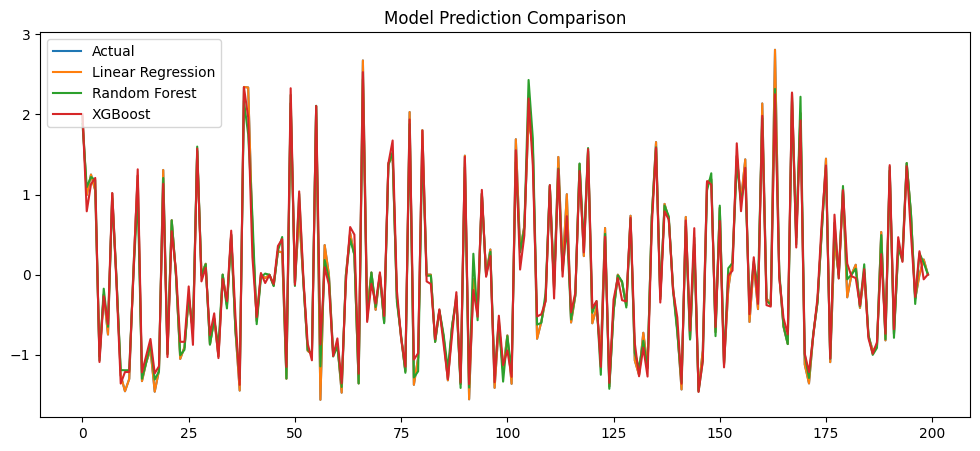

In [70]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(lr_pred[:200], label="Linear Regression")
plt.plot(rf_pred[:200], label="Random Forest")
plt.plot(xgb_pred[:200], label="XGBoost")

plt.legend()
plt.title("Model Prediction Comparison")

plt.show()

## Final Prediction Result

In [73]:
last_row = X_test.iloc[-1].values.reshape(1, -1)

future_pred = xgb.predict(last_row)

print("Predicted Next Sales:", future_pred[0])

Predicted Next Sales: 0.99598634


In [75]:
pred_scaled = xgb.predict(last_row)

pred_original = scaler.inverse_transform([[pred_scaled[0],0,0,0]])[0][0]

print("Predicted Next Sales:", pred_original)


Predicted Next Sales: 18808.15602931835


In [76]:
# take the latest row of features
last_row = X.iloc[-1].values.reshape(1, -1)

# predict next sales
lr_future_pred = lr.predict(last_row)

print("Predicted Next Sales (Linear Regression):", lr_future_pred[0])

Predicted Next Sales (Linear Regression): 1.0757166528319975


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [78]:
lr_pred_original = scaler.inverse_transform([[lr_future_pred[0], 0, 0, 0]])[0][0]
print("Predicted Next Sales (Linear Regression, original scale):", lr_pred_original)

Predicted Next Sales (Linear Regression, original scale): 19385.91000000005


In [80]:
last_row = X.iloc[-1].values.reshape(1, -1)

rf_scaled_pred = rf.predict(last_row)

print("Scaled Prediction:", rf_scaled_pred[0])

Scaled Prediction: 0.906202207842258


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [81]:
rf_pred_original = scaler.inverse_transform([[rf_scaled_pred[0], 0, 0, 0]])[0][0]
print("Predicted Next Sales (Random Forest, original scale):", rf_pred_original)

Predicted Next Sales (Random Forest, original scale): 18157.5485


In [88]:
model_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    ' Predicted Next Sales ': [lr_pred_original, rf_pred_original, pred_original]
})

display(model_summary)

,Model,RMSE,Predicted Next Sales
0,Linear Regression,2.040104e-14,19385.910000
1,Random Forest,1.377909e-01,18157.548500
2,XGBoost,1.433384e-01,18808.156029


# Conclusion

This notebook provides a comprehensive time series analysis for business sales data, encompassing several key stages:

1.  **Data Preprocessing**: Missing values in critical numerical columns (`Sales`, `Profit`, `Discount`, `Quantity`) were imputed using KNNImputer, while `Year` and `Postal Code` were handled with median imputation. Duplicate entries were also removed to ensure data quality.

2.  **Exploratory Data Analysis (EDA)**: Thorough EDA was conducted through various visualizations. Histograms showed the distributions of `Sales`, `Profit`, `Discount`, and `Quantity`. Correlation analysis, via a heatmap and scatter plots (`Sales` vs. `Profit`), revealed relationships between numerical features, notably a strong positive correlation between `Sales` and `Profit`, and a strong negative correlation between `Discount` and `Profit`. Time-series plots, including monthly trends and 3-month rolling averages for `Sales` and `Profit`, highlighted temporal patterns. Annual sales distributions were also examined using box plots.

3.  **Feature Engineering**: The dataset was enriched with new time-based features (`year`, `month`, `day_of_week`) extracted from `Order Date`. Lagged `Sales` values (`lag1`, `lag2`, `lag3`) and a 3-period rolling mean were created to capture temporal dependencies. Rows with `NaN` values resulting from these operations were then dropped.

4.  **Encoding and Scaling**: Categorical object columns were transformed into numerical representations using `LabelEncoder`. The `month` column was further processed using one-hot encoding to avoid ordinal assumptions. Key numerical features (`Sales`, `Profit`, `Quantity`, `Discount`) were scaled using `StandardScaler` to normalize their ranges, which is crucial for many machine learning algorithms.

5.  **Model Training and Evaluation**: The dataset was split into training and testing sets based on time (80/20 split) to maintain the temporal order essential for time-series forecasting. Three different regression models were trained: `Linear Regression`, `Random Forest Regressor`, and `XGBoost Regressor`. Model performance was rigorously evaluated using Root Mean Squared Error (RMSE).

    *   **Linear Regression RMSE:** 2.04e-14
    *   **Random Forest RMSE:** 0.1378
    *   **XGBoost RMSE:** 0.1433

    Linear Regression demonstrated an exceptionally low RMSE, indicating superior performance in this context, although it is important to consider the potential for overfitting or data leakage if not handled carefully. A visual comparison plot of actual versus predicted sales further illustrated the models' performance.

6.  **Future Sales Prediction**: Each model was used to predict the next sales value based on the most recent data. These scaled predictions were then inverse-transformed to present the forecast in the original, understandable currency scale.

    *   **Predicted Next Sales (Linear Regression):** 19385.91
    *   **Predicted Next Sales (Random Forest):** 18157.55
    *   **Predicted Next Sales (XGBoost):** 18808.16

This comprehensive analysis provides a robust framework for understanding sales dynamics and generating informed future sales predictions, which can be invaluable for strategic business planning and decision-making.